## Importing Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1 import make_axes_locatable


In [2]:
data = pd.read_csv('../CSV/NYPD_Complaints_Eric.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999884 entries, 0 to 999883
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   unique_key                999884 non-null  int64  
 1   created_date              999884 non-null  object 
 2   closed_date               999884 non-null  object 
 3   complaint_type            999884 non-null  object 
 4   descriptor                959426 non-null  object 
 5   resolution_description    999783 non-null  object 
 6   location_type             999880 non-null  object 
 7   incident_address          989132 non-null  object 
 8   city                      931706 non-null  object 
 9   police_precinct           999884 non-null  object 
 10  council_district          982941 non-null  float64
 11  borough                   999884 non-null  object 
 12  latitude                  992844 non-null  float64
 13  longitude                 992844 non-null  f

## NYC Boroughs


In [4]:
# importing borough boundaries
path = 'https://data.cityofnewyork.us/resource/gthc-hcne.geojson'
borough_gdf = gpd.read_file(path).to_crs(2263)

# previewing first five rows in data
print(f'shape of data: {borough_gdf.shape}')
borough_gdf.head()

shape of data: (5, 5)


,borocode,boroname,shape_area,shape_leng,geometry
0,5,Staten Island,1623618358.46,325912.288988,"MULTIPOLYGON (((970217.085 145643.397, 970227...."
1,2,Bronx,1187199300.26,463147.071763,"MULTIPOLYGON (((1012821.787 229228.479, 101278..."
2,4,Queens,3041419179.08,887905.076135,"MULTIPOLYGON (((1032452.096 154469.461, 103245..."
3,1,Manhattan,636631164.229,359536.412002,"MULTIPOLYGON (((981219.022 188655.462, 980940...."
4,3,Brooklyn,1934462608.14,726953.045036,"MULTIPOLYGON (((1022227.393 152028.338, 102207..."


## Neighborhood Tabulation Areas (NTAs)

In [5]:
url = 'https://data.cityofnewyork.us/resource/9nt8-h7nd.geojson'
nta_gdf = gpd.read_file(url).to_crs(epsg=2263)

# previewing first five rows in data
print(f'shape of data: {nta_gdf.shape}')
nta_gdf.head()

shape of data: (262, 12)


,shape_area,ntaname,cdtaname,shape_leng,boroname,ntatype,nta2020,borocode,countyfips,ntaabbrev,cdta2020,geometry
0,35321808.3909,Greenpoint,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28919.5611508,Brooklyn,0,BK0101,3,047,Grnpt,BK01,"MULTIPOLYGON (((1003059.974 204572.243, 100299..."
1,28852852.9133,Williamsburg,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28134.0826611,Brooklyn,0,BK0102,3,047,Wllmsbrg,BK01,"MULTIPOLYGON (((995851.879 203199.535, 995969...."
2,15208960.645,South Williamsburg,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),18250.2800908,Brooklyn,0,BK0103,3,047,SWllmsbrg,BK01,"MULTIPOLYGON (((998047.189 196303.521, 998157...."
3,52267406.735,East Williamsburg,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),43184.8003755,Brooklyn,0,BK0104,3,047,EWllmsbrg,BK01,"MULTIPOLYGON (((1005302.485 199455.944, 100530..."
4,9982022.78755,Brooklyn Heights,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,14312.1922849,Brooklyn,0,BK0201,3,047,BkHts,BK02,"MULTIPOLYGON (((986367.702 190549.402, 985813...."


## Data Wrangling

In [6]:
data['created_date'] = pd.to_datetime(data['created_date'])
data['closed_date'] = pd.to_datetime(data['closed_date'])
data['year'] = data['created_date'].dt.year


In [7]:
# create new columns in nta dataframe
nta_gdf['ntaname_boro'] = nta_gdf['ntaname'] + ', ' + nta_gdf['boroname']
nta_gdf['shape_area'] = nta_gdf['shape_area'].astype(float)
nta_gdf['shape_leng'] = nta_gdf['shape_leng'].astype(float)
nta_gdf['shape_area_sq_mi'] = nta_gdf['shape_area'] / 27878400

# examine new columns
nta_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   shape_area        262 non-null    float64 
 1   ntaname           262 non-null    object  
 2   cdtaname          262 non-null    object  
 3   shape_leng        262 non-null    float64 
 4   boroname          262 non-null    object  
 5   ntatype           262 non-null    object  
 6   nta2020           262 non-null    object  
 7   borocode          262 non-null    object  
 8   countyfips        262 non-null    object  
 9   ntaabbrev         262 non-null    object  
 10  cdta2020          262 non-null    object  
 11  geometry          262 non-null    geometry
 12  ntaname_boro      262 non-null    object  
 13  shape_area_sq_mi  262 non-null    float64 
dtypes: float64(3), geometry(1), object(10)
memory usage: 28.8+ KB


In [8]:
# specify CRS, these coordinates are in 2263 from the documentation
crs = 2263

# generate geometry from x, y points
geometry = gpd.points_from_xy(
    data['x_coordinate_state_plane'],
    data['y_coordinate_state_plane']
)

# create geodataframe
gdf = gpd.GeoDataFrame(
    data,
    geometry=geometry,
    crs=crs
)

# preview data
print(f'shape of data: {gdf.shape}')
gdf.iloc[:5, -5:]

shape of data: (999884, 22)


,duration in hours,violation_observed,took_action,year,geometry
0,0.069722,1.0,0.0,2025,POINT (983228.000 158078.000)
1,13.860278,1.0,0.0,2025,POINT (1018544.000 186804.000)
2,3.660278,1.0,0.0,2025,POINT (1028382.000 222231.000)
3,1.415278,1.0,0.0,2025,POINT (1011294.000 270972.000)
4,0.655556,1.0,0.0,2025,POINT (992688.000 162358.000)


<Axes: >

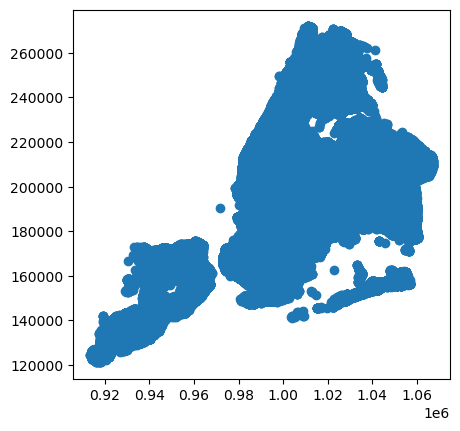

In [9]:
gdf.plot()

## Spatial Join Neighborhood Tabulation Areas (NTAs) Information to Complaints

In [10]:
# spatial join nta information to points
gdf_merged = gpd.sjoin(
    gdf,
    nta_gdf,
    how="inner",
    predicate='within'
)

# drop right index column and reset gdf index
gdf_merged = (
    gdf_merged
    .drop(columns=['index_right'])
    .reset_index(drop=True)
)

# sanity checks
print(f'shape of data: {gdf_merged.shape}')
print(f'count dropped rows: {gdf.shape[0] - gdf_merged.shape[0]}')
print(f'{gdf_merged.crs}')

# preview data
gdf_merged.head()

shape of data: (992594, 35)
count dropped rows: 7290
EPSG:2263


,unique_key,created_date,closed_date,complaint_type,descriptor,resolution_description,location_type,incident_address,city,police_precinct,...,shape_leng,boroname,ntatype,nta2020,borocode,countyfips,ntaabbrev,cdta2020,ntaname_boro,shape_area_sq_mi
0,67231266,2025-12-18 09:07:05,2025-12-18 09:11:16,Blocked Driveway,Partial Access,The New York City Police Department responded ...,Street/Sidewalk,222 BAY 23 STREET,BROOKLYN,Precinct 62,...,22422.373363,Brooklyn,0,BK1102,3,047,BthBch,BK11,"Bath Beach, Brooklyn",0.737361
1,67215949,2025-12-17 22:30:46,2025-12-18 03:34:41,Illegal Parking,Blocked Hydrant,The New York City Police Department responded ...,Street/Sidewalk,8630 16 AVENUE,BROOKLYN,Precinct 62,...,22422.373363,Brooklyn,0,BK1102,3,047,BthBch,BK11,"Bath Beach, Brooklyn",0.737361
2,67222856,2025-12-17 23:19:42,2025-12-18 03:59:33,Illegal Parking,Blocked Hydrant,The New York City Police Department responded ...,Street/Sidewalk,8812 15 AVENUE,BROOKLYN,Precinct 62,...,22422.373363,Brooklyn,0,BK1102,3,047,BthBch,BK11,"Bath Beach, Brooklyn",0.737361
3,67225582,2025-12-18 01:47:12,2025-12-18 04:46:29,Illegal Parking,Blocked Hydrant,The New York City Police Department responded ...,Street/Sidewalk,97 BAY 7 STREET,BROOKLYN,Precinct 62,...,22422.373363,Brooklyn,0,BK1102,3,047,BthBch,BK11,"Bath Beach, Brooklyn",0.737361
4,67225583,2025-12-18 00:02:29,2025-12-18 04:24:58,Illegal Parking,Blocked Hydrant,The New York City Police Department responded ...,Street/Sidewalk,1951 19 LANE,BROOKLYN,Precinct 62,...,22422.373363,Brooklyn,0,BK1102,3,047,BthBch,BK11,"Bath Beach, Brooklyn",0.737361


In [11]:
# column info
gdf_merged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 992594 entries, 0 to 992593
Data columns (total 35 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   unique_key                992594 non-null  int64         
 1   created_date              992594 non-null  datetime64[ns]
 2   closed_date               992594 non-null  datetime64[ns]
 3   complaint_type            992594 non-null  object        
 4   descriptor                952870 non-null  object        
 5   resolution_description    992493 non-null  object        
 6   location_type             992594 non-null  object        
 7   incident_address          982730 non-null  object        
 8   city                      931471 non-null  object        
 9   police_precinct           992594 non-null  object        
 10  council_district          982692 non-null  float64       
 11  borough                   992594 non-null  object        

In [12]:
# examine two borough columns, check borough comparison between complaint and nta
condition = (gdf_merged['borough'].str.title() != gdf_merged['boroname'].str.title())
count = gdf_merged.loc[condition].shape[0]

print(f"count of borough names that don't reconcile: {count:,}")

count of borough names that don't reconcile: 385


In [13]:
# drop borough column from 311 dataset, we assume NTA borough name is closer to actual point location
criteria = gdf_merged.columns.isin(['borough'])

# use this pandas style so we can run this cell again if needed
gdf_merged = gdf_merged.loc[:, gdf_merged.columns[~criteria]]

print(f'shape of data: {gdf_merged.shape}\n')
gdf_merged.info()

shape of data: (992594, 34)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 992594 entries, 0 to 992593
Data columns (total 34 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   unique_key                992594 non-null  int64         
 1   created_date              992594 non-null  datetime64[ns]
 2   closed_date               992594 non-null  datetime64[ns]
 3   complaint_type            992594 non-null  object        
 4   descriptor                952870 non-null  object        
 5   resolution_description    992493 non-null  object        
 6   location_type             992594 non-null  object        
 7   incident_address          982730 non-null  object        
 8   city                      931471 non-null  object        
 9   police_precinct           992594 non-null  object        
 10  council_district          982692 non-null  float64       
 11  latitude                  99

## Creating Maps


In [14]:
# calculate median complaint close out duration 
grouped_gdf = (
    gdf_merged
    .groupby('ntaname_boro')['duration in hours']
    .median()
    .reset_index()
)

# merge to geodataframe to plot
nta_shape_time = nta_gdf.merge(
    grouped_gdf, 
    left_on='ntaname_boro', 
    right_on='ntaname_boro'
)

nta_shape_time.head()

,shape_area,ntaname,cdtaname,shape_leng,boroname,ntatype,nta2020,borocode,countyfips,ntaabbrev,cdta2020,geometry,ntaname_boro,shape_area_sq_mi,duration in hours
0,3.532181e+07,Greenpoint,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28919.561151,Brooklyn,0,BK0101,3,047,Grnpt,BK01,"MULTIPOLYGON (((1003059.974 204572.243, 100299...","Greenpoint, Brooklyn",1.266996,1.195000
1,2.885285e+07,Williamsburg,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28134.082661,Brooklyn,0,BK0102,3,047,Wllmsbrg,BK01,"MULTIPOLYGON (((995851.879 203199.535, 995969....","Williamsburg, Brooklyn",1.034954,1.046667
2,1.520896e+07,South Williamsburg,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),18250.280091,Brooklyn,0,BK0103,3,047,SWllmsbrg,BK01,"MULTIPOLYGON (((998047.189 196303.521, 998157....","South Williamsburg, Brooklyn",0.545546,1.118056
3,5.226741e+07,East Williamsburg,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),43184.800376,Brooklyn,0,BK0104,3,047,EWllmsbrg,BK01,"MULTIPOLYGON (((1005302.485 199455.944, 100530...","East Williamsburg, Brooklyn",1.874835,0.988056
4,9.982023e+06,Brooklyn Heights,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,14312.192285,Brooklyn,0,BK0201,3,047,BkHts,BK02,"MULTIPOLYGON (((986367.702 190549.402, 985813....","Brooklyn Heights, Brooklyn",0.358056,1.096528


In [15]:
Q1 = nta_shape_time['duration in hours'].quantile(0.25)
Q3 = nta_shape_time['duration in hours'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

nta_shape_time = nta_shape_time[
    (nta_shape_time['duration in hours'] >= lower_bound) &
    (nta_shape_time['duration in hours'] <= upper_bound)
]

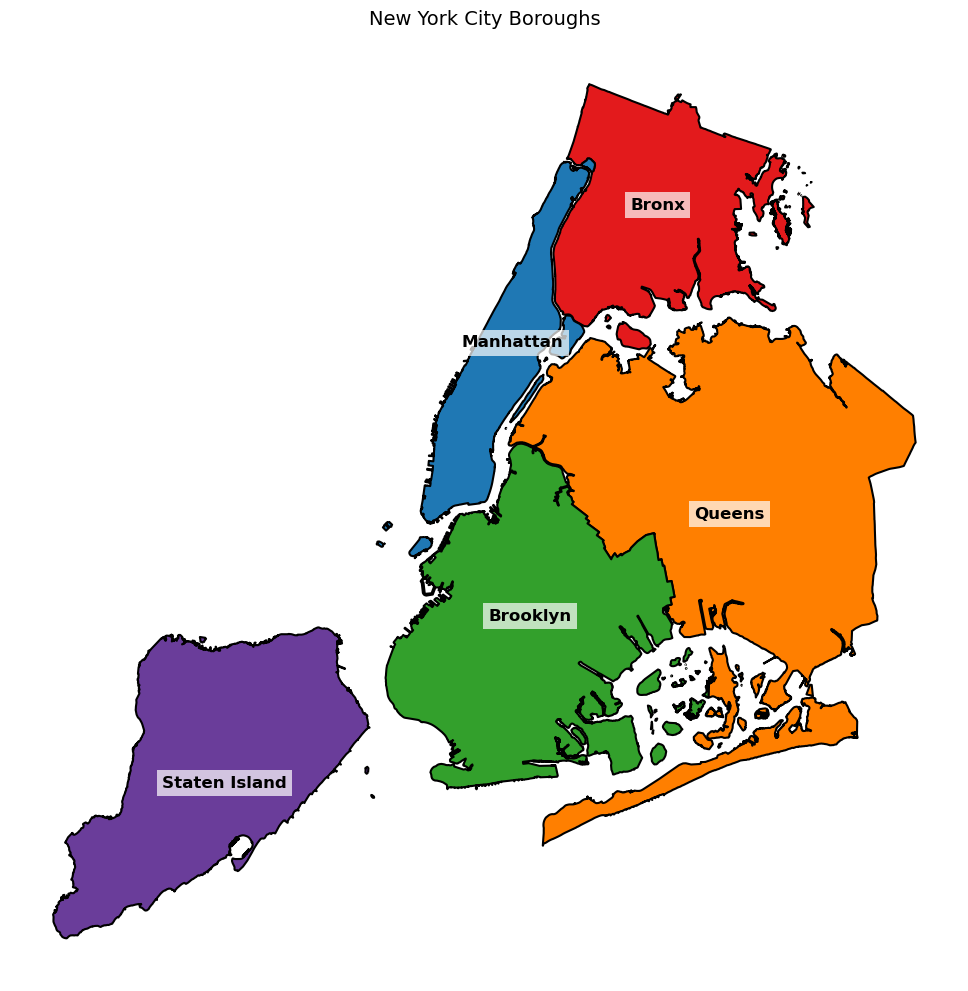

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))

# assign a categorical color per borough
doitt_colors = {
    'Manhattan': '#1F78B4',
    'Bronx': '#E31A1C',
    'Brooklyn': '#33A02C',
    'Queens': '#FF7F00',
    'Staten Island': '#6A3D9A'
}

borough_gdf['color'] = borough_gdf['boroname'].map(doitt_colors)

# ensure CRS consistency (good practice)
borough_gdf = borough_gdf.to_crs(borough_gdf.crs)

# plot borough polygons with fill
borough_gdf.plot(
    ax=ax,
    color=borough_gdf['color'],
    edgecolor='black',
    linewidth=1.5
)

# compute label positions
borough_gdf['label_point'] = borough_gdf.geometry.representative_point()

# add borough labels
for _, row in borough_gdf.iterrows():
    ax.text(
        row.label_point.x,
        row.label_point.y,
        row['boroname'],
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

# title and cleanup
ax.set_title(
    'New York City Boroughs',
    fontsize=14,
    pad=12
)

ax.axis('off')
plt.tight_layout()

plt.savefig(
    "../plots/nyc_boroughs_only.png",
    bbox_inches="tight",
    dpi=300
)

/var/folders/wy/psj108nd3478hbn8njppcqqc0000gn/T/ipykernel_10486/3332571393.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


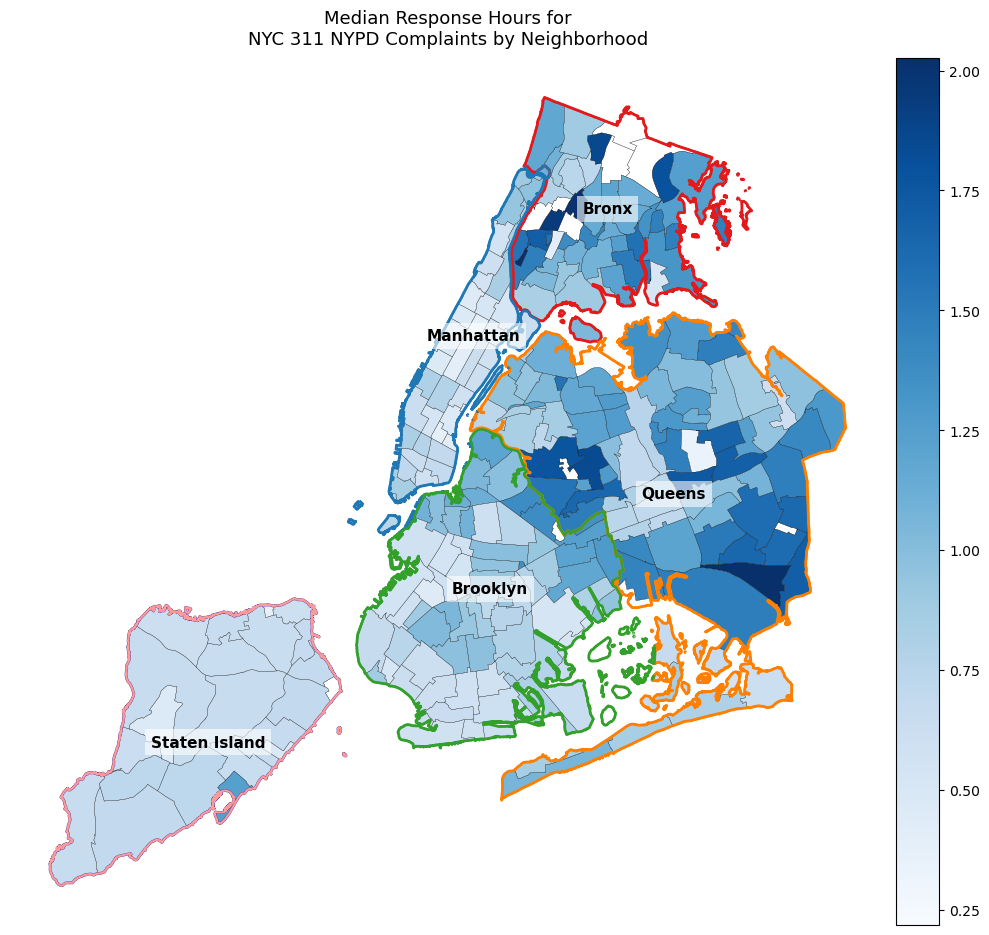

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cmap = plt.cm.Blues



nta_shape_time.plot(
    column='duration in hours', 
    cmap=cmap,
    ax=ax, 
    legend=True,
    cax=cax,
    
)

nta_gdf.plot(
    facecolor="none",
    edgecolor="black",
    linewidth=0.15,   # thinner
    ax=ax
)

borough_gdf.boundary.plot(
    ax=ax,
    color=borough_gdf['color'],
    linewidth=2.0     # thicker
)

title = 'Median Response Hours for\nNYC 311 NYPD Complaints by Neighborhood'
ax.set_title(title, fontsize=13, pad=10)
ax.axis('off')

plt.tight_layout()

# ensure same CRS
borough_gdf = borough_gdf.to_crs(nta_shape_time.crs)

# compute label positions
borough_gdf['label_point'] = borough_gdf.geometry.representative_point()

# add borough labels
for _, row in borough_gdf.iterrows():
    ax.text(
        row.label_point.x,
        row.label_point.y,
        row['boroname'],   
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

# assign a categorical color per borough
doitt_colors = {
    'Manhattan': '#1F78B4',
    'Bronx': '#E31A1C',
    'Brooklyn': '#33A02C',
    'Queens': '#FF7F00',
    'Staten Island': '#FB9A99'
}

borough_gdf['color'] = borough_gdf['boroname'].map(doitt_colors)

borough_gdf.boundary.plot(
    ax=ax,
    color=borough_gdf['color'],
    linewidth=1.5
)

plt.tight_layout()
plt.savefig(
    "../plots/nyc_311_response_map.png",
    bbox_inches="tight"
)